In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


What is the Advantage of a GPU?

GPU (Graphics Processing Unit) can perform thousands of calculations simultaneously, while a CPU (Central Processing Unit) performs fewer calculations at a time.

Simple Example

Suppose you have 10,000 images to train a VGG16 model.

CPU
Image 1 → Process
Image 2 → Process
Image 3 → Process
...

Works mostly sequentially.

GPU
Image 1  \
Image 2   \
Image 3    > Process many images together
Image 4   /
Image 5  /

Works in parallel.



=========

Training Time Comparison

| Task                    | CPU    | GPU   |
| ----------------------- | ------ | ----- |
| Small CNN               | 10 min | 2 min |
| VGG16 Transfer Learning | 30 min | 5 min |
| ResNet Training         | 40 min | 7 min |

=====
Why Deep Learning Needs GPU

Models like:

VGG16,
ResNet18,
YOLO.

contain millions of parameters.

Example:

VGG16 ≈ 138 million parameters

During training, the model performs millions of matrix multiplications. GPUs are specially designed for these operations.

| Line No. | Code                                                              | Purpose                                                                  |
| -------- | ----------------------------------------------------------------- | ------------------------------------------------------------------------ |
| 1        | `import tensorflow as tf`                                         | Imports the TensorFlow library and assigns it the alias `tf`.            |
| 2        | `tf.config.list_physical_devices('GPU')`                          | Checks whether any GPU devices are available in the current environment. |
| 3        | `print("GPU Available:", tf.config.list_physical_devices('GPU'))` | Displays the list of available GPUs on the screen.                       |


Download Dataset

Use the TrashNet dataset.

In [2]:
!wget https://github.com/garythung/trashnet/archive/master.zip
!unzip master.zip

--2026-06-10 03:51:18--  https://github.com/garythung/trashnet/archive/master.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/garythung/trashnet/zip/refs/heads/master [following]
--2026-06-10 03:51:18--  https://codeload.github.com/garythung/trashnet/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.112.10
Connecting to codeload.github.com (codeload.github.com)|140.82.112.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [      <=>           ]  40.63M  19.4MB/s    in 2.1s    

2026-06-10 03:51:20 (19.4 MB/s) - ‘master.zip’ saved [42609527]

Archive:  master.zip
6fa2b878c6c1b4304b91109070ce0edf9279bb31
   creating: trashnet-master/
  inflating: trashnet-master/.gitignore  
  inflating: tr

| Line No. | Code                                                             | Purpose                                                                                |
| -------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| 1        | `!wget https://github.com/garythung/trashnet/archive/master.zip` | Downloads the TrashNet dataset ZIP file from GitHub into the Google Colab environment. |
| 2        | `!unzip master.zip`                                              | Extracts (unzips) the downloaded dataset files and folders.                            |

======

| Command      | Description                                              |
| ------------ | -------------------------------------------------------- |
| `!`          | Executes a Linux terminal command inside Google Colab.   |
| `wget`       | Downloads files from the internet using a URL.           |
| `master.zip` | The compressed ZIP file containing the TrashNet dataset. |
| `unzip`      | Extracts all files and folders from the ZIP archive.     |

====
| Step     | Input        | Output                    |
| -------- | ------------ | ------------------------- |
| Download | GitHub URL   | `master.zip` file         |
| Extract  | `master.zip` | `trashnet-master/` folder |


Import Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
import matplotlib.pyplot as plt

| Line No. | Code                                                                  | Purpose                                                                                              |
| -------- | --------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| 1        | `import tensorflow as tf`                                             | Imports TensorFlow, the main deep learning framework used for building and training neural networks. |
| 2        | `from tensorflow.keras.preprocessing.image import ImageDataGenerator` | Imports ImageDataGenerator to load, preprocess, and augment image datasets.                          |
| 3        | `from tensorflow.keras.applications import VGG16`                     | Imports the pre-trained VGG16 model for transfer learning.                                           |
| 4        | `from tensorflow.keras.models import Model`                           | Imports the Model class to create a custom neural network architecture.                              |
| 5        | `from tensorflow.keras.layers import Dense, Flatten, Dropout`         | Imports layers used to build the classifier on top of VGG16.                                         |
| 6        | `import matplotlib.pyplot as plt`                                     | Imports Matplotlib for plotting graphs such as accuracy and loss curves.                             |
=========

| Component            | Purpose                                           |
| -------------------- | ------------------------------------------------- |
| `TensorFlow (tf)`    | Deep learning framework                           |
| `ImageDataGenerator` | Loads and preprocesses images                     |
| `VGG16`              | Pre-trained CNN model for feature extraction      |
| `Model`              | Creates the final custom model                    |
| `Dense`              | Fully connected neural network layer              |
| `Flatten`            | Converts 2D/3D feature maps into a 1D vector      |
| `Dropout`            | Reduces overfitting by randomly disabling neurons |
| `Matplotlib (plt)`   | Visualizes training results                       |

====
| Import                    | Why Used in Waste Classification Project        |
| ------------------------- | ----------------------------------------------- |
| `tensorflow`              | Train and run the deep learning model           |
| `ImageDataGenerator`      | Read waste images from folders                  |
| `VGG16`                   | Extract image features using transfer learning  |
| `Model`                   | Combine VGG16 with custom layers                |
| `Dense, Flatten, Dropout` | Build the waste classification head             |
| `matplotlib`              | Display accuracy and loss graphs after training |
====

Create Data Generators

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "trashnet-master/data",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "trashnet-master/data",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


| Line No. | Code                                                                       | Purpose                                                                                                        |
| -------- | -------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| 1-4      | `train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)` | Creates an image data generator for preprocessing images and splitting data into training and validation sets. |
| 2        | `rescale=1./255`                                                           | Converts pixel values from 0–255 to 0–1 for better model training.                                             |
| 3        | `validation_split=0.2`                                                     | Reserves 20% of the dataset for validation and 80% for training.                                               |
| 6-12     | `train_generator = train_datagen.flow_from_directory(...)`                 | Loads training images from the dataset folder.                                                                 |
| 7        | `"trashnet-master/data"`                                                   | Path containing waste image class folders.                                                                     |
| 8        | `target_size=(224,224)`                                                    | Resizes all images to 224×224 pixels (required by VGG16).                                                      |
| 9        | `batch_size=32`                                                            | Loads 32 images at a time during training.                                                                     |
| 10       | `class_mode='categorical'`                                                 | Used for multi-class classification (cardboard, glass, metal, paper, plastic, trash).                          |
| 11       | `subset='training'`                                                        | Uses 80% of images for model training.                                                                         |
| 14-20    | `val_generator = train_datagen.flow_from_directory(...)`                   | Loads validation images from the dataset folder.                                                               |
| 19       | `subset='validation'`                                                      | Uses 20% of images for validation during training.                                                             |

=====

| Parameter             | Value           | Purpose                                          |
| --------------------- | --------------- | ------------------------------------------------ |
| `rescale`             | `1./255`        | Normalizes pixel values to the range 0–1         |
| `validation_split`    | `0.2`           | Splits data into 80% training and 20% validation |
| `target_size`         | `(224,224)`     | Matches VGG16 input size                         |
| `batch_size`          | `32`            | Processes 32 images per training step            |
| `class_mode`          | `'categorical'` | Enables multi-class classification               |
| `subset='training'`   | Training set    | Used to learn patterns                           |
| `subset='validation'` | Validation set  | Used to evaluate model performance               |


====
| Total Images | Training (80%) | Validation (20%) |
| ------------ | -------------- | ---------------- |
| 2500         | 2000           | 500              |
| 5000         | 4000           | 1000             |
===


In [5]:
!ls

master.zip  sample_data  trashnet-master


In [6]:
!ls trashnet-master

data		LICENSE    plot.lua   shuffle.lua  train.lua  weight-init.lua
DataLoader.lua	model.lua  README.md  test.lua	   utils.lua


In [7]:
!find . -type d | grep data

./trashnet-master/data
./sample_data


In [8]:
!ls trashnet-master/data

constants.py			     one-indexed-files-notrash_val.txt
dataset-resized.zip		     one-indexed-files.txt
one-indexed-files-notrash_test.txt   resize.py
one-indexed-files-notrash_train.txt  zero-indexed-files.txt


Inside data, there is another ZIP file, unzip this use following code

In [9]:
!unzip trashnet-master/data/dataset-resized.zip

Archive:  trashnet-master/data/dataset-resized.zip
   creating: dataset-resized/
  inflating: dataset-resized/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/dataset-resized/
  inflating: __MACOSX/dataset-resized/._.DS_Store  
   creating: dataset-resized/cardboard/
  inflating: dataset-resized/cardboard/cardboard1.jpg  
  inflating: dataset-resized/cardboard/cardboard10.jpg  
  inflating: dataset-resized/cardboard/cardboard100.jpg  
  inflating: dataset-resized/cardboard/cardboard101.jpg  
  inflating: dataset-resized/cardboard/cardboard102.jpg  
  inflating: dataset-resized/cardboard/cardboard103.jpg  
  inflating: dataset-resized/cardboard/cardboard104.jpg  
  inflating: dataset-resized/cardboard/cardboard105.jpg  
  inflating: dataset-resized/cardboard/cardboard106.jpg  
  inflating: dataset-resized/cardboard/cardboard107.jpg  
  inflating: dataset-resized/cardboard/cardboard108.jpg  
  inflating: dataset-resized/cardboard/cardboard109.jpg  
  inflating: dataset-resized/ca

In [10]:
#Check Extraction
!ls dataset-resized

cardboard  glass  metal  paper	plastic  trash


Load, resize, normalize, and split the TrashNet dataset before training the VGG16 model

===

dataset-resized
       ↓
ImageDataGenerator
       ↓
Normalize Images (0–1)
       ↓
Split Dataset (80% / 20%)
       ↓
train_generator      val_generator
       ↓                    ↓
      VGG16 Model Training & Validation

      ============

  Waste Images
      ↓
Load Images from Folders
      ↓
Resize to 224×224
      ↓
Normalize Pixel Values
      ↓
Split into Training (80%)
and Validation (20%)
      ↓
Feed Images to VGG16 Model
      ↓
Train Waste Classification System


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "dataset-resized",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "dataset-resized",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


The next code after creating train_generator and val_generator is loading the VGG16 pretrained model.

In [12]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


| Line No. | Code                                              | Purpose                                                        |
| -------- | ------------------------------------------------- | -------------------------------------------------------------- |
| 1        | `from tensorflow.keras.applications import VGG16` | Imports the pretrained VGG16 model.                            |
| 3-7      | `base_model = VGG16(...)`                         | Loads the VGG16 architecture with pretrained ImageNet weights. |
| 4        | `weights='imagenet'`                              | Uses knowledge learned from millions of images.                |
| 5        | `include_top=False`                               | Removes the original 1000-class output layer.                  |
| 6        | `input_shape=(224,224,3)`                         | Sets image size and RGB channels required by VGG16.            |
| 9-10     | `for layer in base_model.layers:`                 | Loops through all VGG16 layers.                                |
| 10       | `layer.trainable = False`                         | Freezes weights so VGG16 acts as a feature extractor.          |
=====

| Parameter                 | Purpose                                                          |
| ------------------------- | ---------------------------------------------------------------- |
| `weights='imagenet'`      | Uses pretrained knowledge instead of training from scratch       |
| `include_top=False`       | Removes ImageNet classifier because we need waste classification |
| `input_shape=(224,224,3)` | Matches the resized image dimensions                             |
| `trainable=False`         | Prevents VGG16 weights from changing during training             |
=======

Waste Image
      ↓
VGG16 Pretrained Model
      ↓
Extract Features
      ↓
Custom Classification Layers
      ↓
Cardboard / Glass / Metal
Paper / Plastic / Trash

Add Custom Classification Layers

In [13]:
x = base_model.output
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

| Line No. | Code                                   | Purpose                                                                                   |
| -------- | -------------------------------------- | ----------------------------------------------------------------------------------------- |
| 1        | `x = base_model.output`                | Takes the feature output from the VGG16 model.                                            |
| 2        | `x = Flatten()(x)`                     | Converts multi-dimensional feature maps into a 1D vector.                                 |
| 3        | `x = Dropout(0.5)(x)`                  | Randomly drops 50% of neurons during training to reduce overfitting.                      |
| 4        | `x = Dense(128, activation='relu')(x)` | Adds a fully connected layer with 128 neurons to learn waste classification patterns.     |
| 6-9      | `output = Dense(...)`                  | Creates the final output layer for waste category prediction.                             |
| 7        | `train_generator.num_classes`          | Automatically sets the number of output neurons equal to the number of waste classes (6). |
| 8        | `activation='softmax'`                 | Converts outputs into class probabilities.                                                |


| Layer               | Purpose                                                             |
| ------------------- | ------------------------------------------------------------------- |
| `Flatten()`         | Converts extracted features into a format suitable for Dense layers |
| `Dropout(0.5)`      | Prevents overfitting                                                |
| `Dense(128, relu)`  | Learns important waste classification patterns                      |
| `Dense(6, softmax)` | Predicts one of the 6 waste categories                              |

=======

Waste Image
      ↓
VGG16
      ↓
Feature Maps
      ↓
Flatten
      ↓
Dropout
      ↓
Dense(128)
      ↓
Dense(6)
      ↓
Predicted Waste Class

In [14]:
#create the final model:
model = Model(
    inputs=base_model.input,
    outputs=output
)

Compile the Model

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

| Line No. | Code                              | Purpose                                                      |
| -------- | --------------------------------- | ------------------------------------------------------------ |
| 1-5      | `model.compile(...)`              | Configures the model for training.                           |
| 2        | `optimizer='adam'`                | Updates model weights efficiently during training.           |
| 3        | `loss='categorical_crossentropy'` | Calculates error for multi-class classification.             |
| 4        | `metrics=['accuracy']`            | Measures prediction accuracy during training and validation. |
=======

| Parameter                         | Purpose                                            |
| --------------------------------- | -------------------------------------------------- |
| `optimizer='adam'`                | Helps the model learn faster and efficiently       |
| `loss='categorical_crossentropy'` | Suitable for multiple classes (6 waste categories) |
| `metrics=['accuracy']`            | Displays accuracy after each epoch                 |


Why categorical_crossentropy?

Your classes are:

cardboard
glass
metal
paper
plastic
trash

Since there are 6 classes, this is a multi-class classification problem, so:

loss='categorical_crossentropy'

is the correct choice.

Model Created
      ↓
Compile Model
      ↓
Set Optimizer
      ↓
Set Loss Function
      ↓
Set Accuracy Metric
      ↓
Ready for Training

This code prepares the VGG16 waste classification model for training by defining how it learns (Adam optimizer), how errors are calculated (categorical crossentropy), and how performance is measured (accuracy).

In [17]:
# Train the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1315s 21s/step - accuracy: 0.5119 - loss: 1.4350 - val_accuracy: 0.5984 - val_loss: 1.0033
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1314s 21s/step - accuracy: 0.7544 - loss: 0.6701 - val_accuracy: 0.6243 - val_loss: 0.9409
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1311s 21s/step - accuracy: 0.8389 - loss: 0.4793 - val_accuracy: 0.6501 - val_loss: 0.8889
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1308s 21s/step - accuracy: 0.8874 - loss: 0.3308 - val_accuracy: 0.6660 - val_loss: 0.9252
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1306s 20s/step - accuracy: 0.9185 - loss: 0.2382 - val_accuracy: 0.6441 - val_loss: 1.1806
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1344s 21s/step - accuracy: 0.9259 - loss: 0.2209 - val_accuracy: 0.6581 - val_loss: 0.9876
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1312s 21s/step - accuracy: 0.9471 - loss: 0.1814 - val_accuracy: 0.6879 - val_loss: 1.0327
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1308s 20s/step - accuracy: 0.9521 - loss: 0.1501 - val_accu

Save Model

In [19]:
model.save("vgg16_transfer_learning.h5")

print("Model Saved Successfully")

Model Saved Successfully


| File / Folder Name           | Type       | Purpose / Use                                                                                           |
| ---------------------------- | ---------- | ------------------------------------------------------------------------------------------------------- |
| `__MACOSX`                   | Folder     | Automatically created when a ZIP file is compressed on macOS. Not needed for training.                  |
| `dataset-resized`            | Folder     | Your image dataset used for training the VGG16 model. Contains class-wise images.                       |
| `sample_data`                | Folder     | Default Google Colab sample files. Not related to your project.                                         |
| `trashnet-master`            | Folder     | Original TrashNet dataset folder extracted from GitHub/ZIP download.                                    |
| `master.zip`                 | ZIP File   | Compressed version of the TrashNet dataset. Used only for extraction.                                   |
| `vgg16_transfer_learning.h5` | Model File | Your trained VGG16 model. Contains learned weights and architecture. Used for prediction/testing later. |


Project work flow:

| Step | File/Folder                  | Purpose                           |
| ---- | ---------------------------- | --------------------------------- |
| 1    | `master.zip`                 | Download dataset                  |
| 2    | `trashnet-master`            | Extract dataset                   |
| 3    | `dataset-resized`            | Training images                   |
| 4    | VGG16 Training               | Train model                       |
| 5    | `vgg16_transfer_learning.h5` | Save trained model                |
| 6    | New Image                    | Test prediction using saved model |


mportant File

✅ vgg16_transfer_learning.h5

This is the most important file now.

Training took about 3.5 hours
The model is already saved
Download and keep a backup copy

Download from Files panel:

Right-click vgg16_transfer_learning.h5
Click Download

In [20]:
from google.colab import files
files.download("vgg16_transfer_learning.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test with a New Image

In [21]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-06-10 13.36.26.png to Screenshot 2026-06-10 13.36.26.png


load your saved model

In [22]:
from tensorflow.keras.models import load_model

model = load_model("vgg16_transfer_learning.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


prediction cell:

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
[[4.2827956e-08 8.6206779e-07 9.9255592e-01 7.4431077e-03 1.7065279e-08
  3.7079337e-09]]


In [24]:
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(prediction) * 100, "%")

Predicted Class: metal
Confidence: 99.25559 %


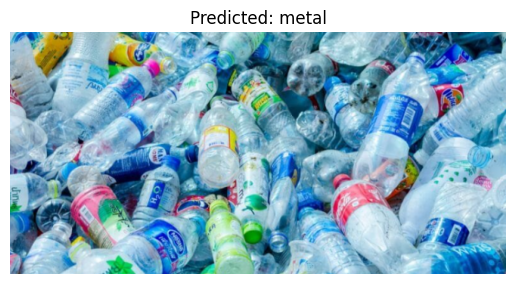

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}")
plt.show()

In [26]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-06-10 13.43.22.png to Screenshot 2026-06-10 13.43.22.png


In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
[[2.6172588e-02 1.7645690e-06 1.0781809e-01 7.8764921e-01 2.2853545e-03
  7.6073073e-02]]


In [28]:
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(prediction) * 100, "%")

Predicted Class: paper
Confidence: 78.76492 %


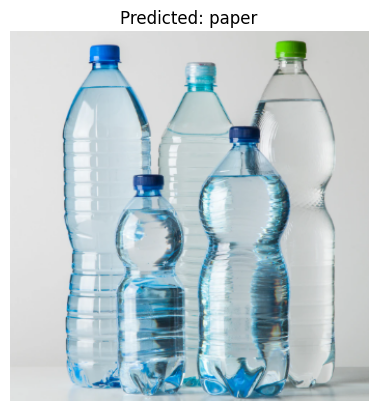

In [29]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}")
plt.show()